# Decision Trees

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

# reproducibility
RND = 42

train_df = pd.read_pickle('../pickles/combined/train_df.pkl')
valid_df = pd.read_pickle('../pickles/combined/valid_df.pkl')
test_df  = pd.read_pickle('../pickles/combined/test_df.pkl')

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test  shape:",  test_df.shape)
print("Columns:", train_df.columns.tolist())

feature_cols = [c for c in train_df.columns if c != 'class']

X_train = train_df[feature_cols].copy()
y_train = train_df['class'].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df['class'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['class'].copy()

# encode class labels to integers (fit on train only)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc  = le.transform(y_test)

print("Classes:", le.classes_)

Train shape: (23566, 7)
Valid shape: (8997, 7)
Test  shape: (5138, 7)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'class']
Classes: ['jumping' 'running' 'stairs' 'walking']


## Grid search for max_depth and criterion

We test a set of reasonable max_depth values to control tree complexity and both gini and entropy criterion. Typical depths like 3,5,7,9 allow checking underfitting vs overfitting. max_depth=None lets the tree grow until leaves are pure (likely overfitting). The CV will tell us the best tradeoff between depth and generalization.

In [2]:
clf = DecisionTreeClassifier(random_state=RND)

param_grid_dt = {
    'max_depth': list(range(1, 13, 2)),
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(clf,
                       param_grid_dt,
                       cv=5,
                       scoring='accuracy',
                       n_jobs=-1,
                       return_train_score=True,
                       refit=True)

grid_dt.fit(X_train, y_train_enc)

print("Best params (DT):", grid_dt.best_params_)
print("Best CV accuracy (DT): {:.4f}".format(grid_dt.best_score_))

Best params (DT): {'criterion': 'gini', 'max_depth': 11}
Best CV accuracy (DT): 0.8421


## Investigate whether criterion matters

We look at mean_test_score grouped by criterion to see if gini vs entropy produces systematic differences. Often differences are small, but it depends on data.

In [3]:
cv_results_dt = pd.DataFrame(grid_dt.cv_results_)
summary = cv_results_dt[['param_criterion', 'param_max_depth', 'mean_test_score']].sort_values(['param_criterion', 'param_max_depth'])
print(summary)

   param_criterion  param_max_depth  mean_test_score
6          entropy                1         0.390138
7          entropy                3         0.674105
8          entropy                5         0.739368
9          entropy                7         0.784390
10         entropy                9         0.822964
11         entropy               11         0.837816
0             gini                1         0.415342
1             gini                3         0.680640
2             gini                5         0.738009
3             gini                7         0.799328
4             gini                9         0.822624
5             gini               11         0.842059


Let's plot the results:

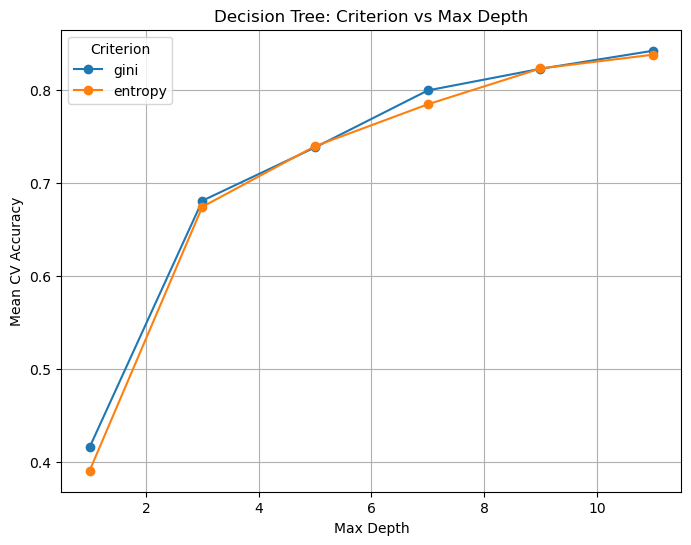

In [4]:
plt.figure(figsize=(8,6))
for crit in cv_results_dt['param_criterion'].unique():
    subset = cv_results_dt[cv_results_dt['param_criterion'] == crit]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], marker='o', label=crit)

plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Decision Tree: Criterion vs Max Depth")
plt.legend(title="Criterion")
plt.grid(True)
plt.show()

Both criteria lead to very similar performance across all depths. The differences are so small that they likely come from random variation in cross-validation folds rather than from a real systematic advantage. The main factor that clearly impacts accuracy is max_depth, not the choice between gini and entropy. 

In conclusion, the choice of criterion does not have a significant impact on accuracy. The depth of the tree is the dominant hyperparameter for performance.

## Plot the (pruned) tree with optimal hyperparameters

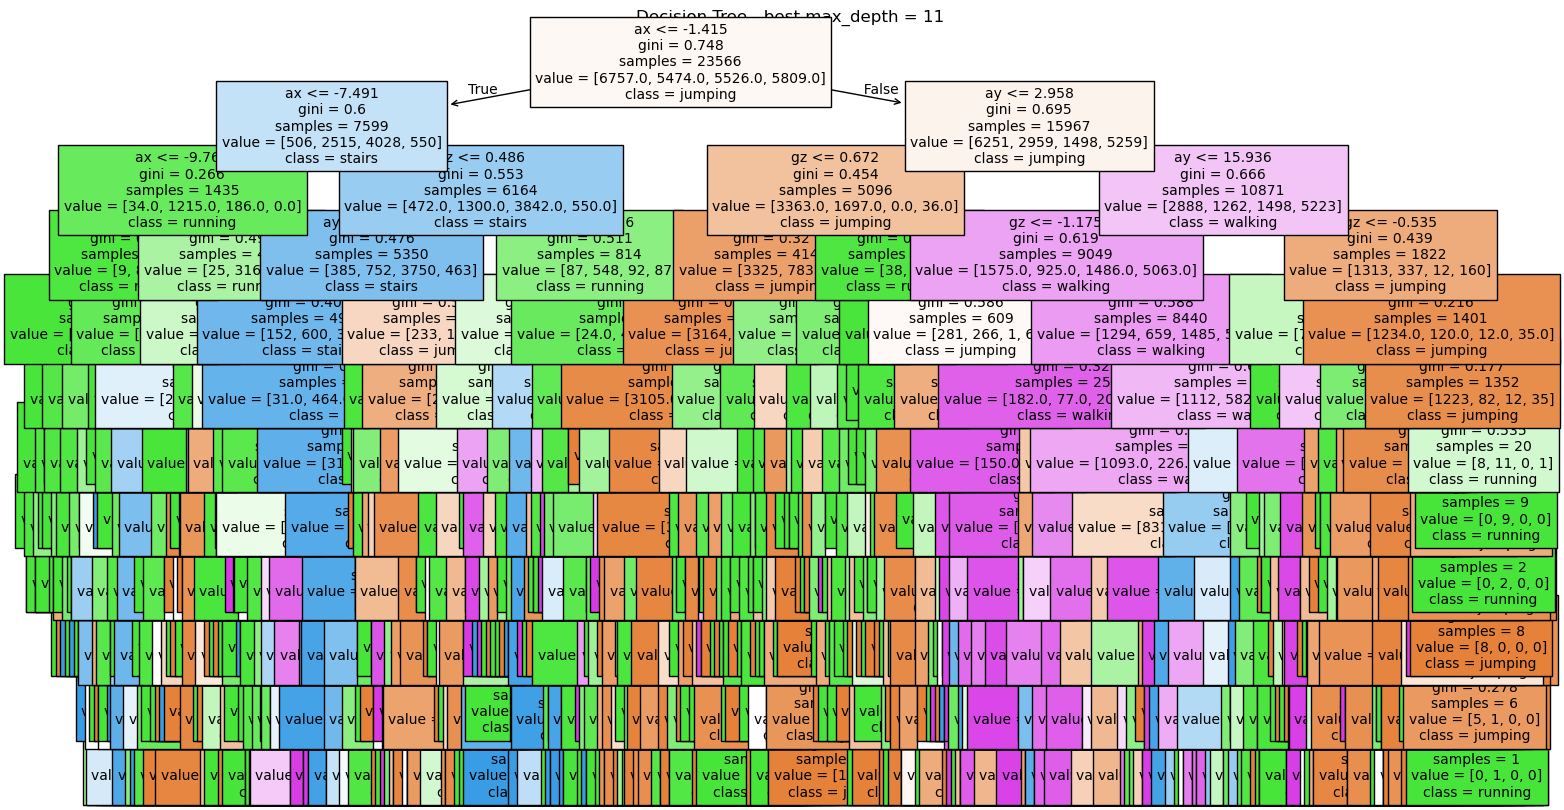

In [5]:
best_dt = grid_dt.best_estimator_
best_max_depth = grid_dt.best_params_['max_depth']

plt.figure(figsize=(18,10))
plot_tree(best_dt,
          feature_names=feature_cols,
          class_names=le.classes_,
          filled=True,
          max_depth=best_max_depth,
          fontsize=10)
plt.title(f"Decision Tree - best max_depth = {best_max_depth}")
plt.show()


## Evaluate Decision Tree on test set

In [6]:
dt_best_model = grid_dt.best_estimator_
y_test_pred_dt = dt_best_model.predict(X_test)
y_test_pred_dt_labels = le.inverse_transform(y_test_pred_dt)
y_test_labels = y_test.values 

dt_test_acc = accuracy_score(y_test_enc, y_test_pred_dt)
print("Decision Tree test accuracy: {:.4f}".format(dt_test_acc))
print("\nClassification report (Decision Tree, test):")
print(classification_report(y_test_labels, y_test_pred_dt_labels, digits=4))

Decision Tree test accuracy: 0.8754

Classification report (Decision Tree, test):
              precision    recall  f1-score   support

     jumping     0.8341    0.8640    0.8488      1088
     running     0.8561    0.8884    0.8719      1138
      stairs     0.9275    0.9033    0.9152      1841
     walking     0.8525    0.8254    0.8387      1071

    accuracy                         0.8754      5138
   macro avg     0.8675    0.8703    0.8687      5138
weighted avg     0.8762    0.8754    0.8756      5138



The validation accuracy is obtained from cross-validation on the training data, and is used to select the best hyperparameters, in this case max depth and criterion. The test accuracy is then evaluated on a separate dataset that has never been used during training.

## Confusion Matrix

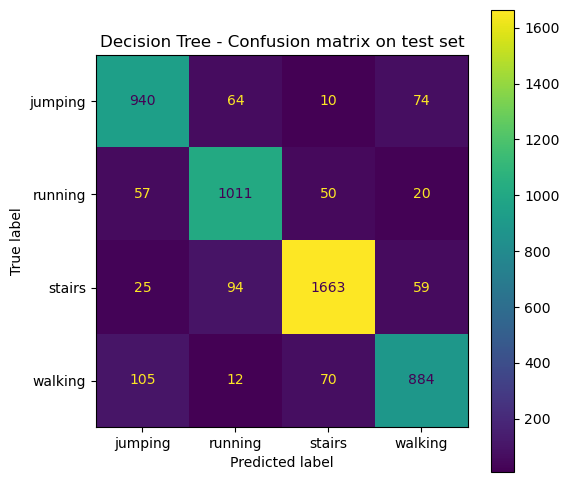

In [7]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test_labels, y_test_pred_dt_labels),
                              display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, values_format='d')
plt.title('Decision Tree - Confusion matrix on test set')
plt.show()


The confusion matrix shows that the Decision Tree model performs very well overall, with most predictions lying on the diagonal (correct class). 'stairs' and 'running' are classified with particularly high accuracy, with 1663 and 1011 correct predictions respectively and only a few misclassifications. However, 'jumping' and 'walking' show more confusion: 'stairs' is sometimes predicted as 'running' (94 cases), while 'walking' is occasionally confused with both 'jumping' (105) and 'stairs' (70).